# Import the necessary libraries and modules

In [1]:
import torch  # PyTorch library for deep learning
import torch.nn as nn  # Neural network modules and loss functions
import pennylane as qml  # PennyLane for quantum machine learning
import numpy as np  # NumPy library for numerical computations
import matplotlib.pyplot as plt  # Plotting library for visualization
from matplotlib.ticker import ScalarFormatter  # Formatter for scientific notation in plots
dtype = torch.float  # Set default tensor data type to float

In [2]:
def Solution(x, y, params):
    # Analytical solution of the wave function for comparison
    Lx, Ly, w, l, m, h_bar, mass = params
    return (2/np.sqrt(Lx*Ly))*torch.sin((l*torch.pi/Lx)*x)*torch.sin((m*torch.pi/Ly)*y)

def E_func(params):
    # Analytical solution of energy for comparison
    Lx, Ly, w, l, m, h_bar, mass = params
    return (1/(2*mass))*((h_bar*torch.pi)**2)*((pow(l, 2)/Lx**2) + (pow(m, 2)/Ly**2))

def test_PINN(NN, domain, num_test, E_exact, Ep, psi_exact, name1, name2):
    # Evaluate the neural network against the analytical solution and compute error metrics
    x = torch.linspace(domain[0][0], domain[0][1], num_test)
    y = torch.linspace(domain[1][0], domain[1][1], num_test)
    
    X, Y = torch.meshgrid(x, y, indexing="ij")
    data = torch.vstack([X.ravel(), Y.ravel()]).T # reshape the grid into a 2D array of points
    with torch.no_grad():
        psi_pred, E_pred = NN(data)

    psi2_pred = psi_pred**2
    
    psi_pred = torch.reshape(psi_pred, (num_test, num_test))
    
    list_berror = []
    list_bmerror = []
    for psi_e in psi_exact:
        psi2_exact = (psi_e**2).view(-1, 1)
        error = torch.abs(psi2_exact - psi2_pred)
        mean_error = torch.mean(error)
        list_berror.append(error)
        list_bmerror.append(mean_error)
    
    min_e = min(list_bmerror)
    min_idx = list_bmerror.index(min_e)
    psi2_error = torch.reshape(list_berror[min_idx], (num_test, num_test))
    psi2_merror = list_bmerror[min_idx]
        
    E_pred = E_pred.item() + Ep
    energy_error = abs((E_pred) - E_exact)
    relative_error = energy_error/E_exact
    MRE = torch.mean(relative_error)
    MRE_precent = MRE*100
    
    return psi_pred, energy_error, MRE_precent, psi2_merror

In [3]:
# Set the necessary parameters
seed = 42
energy_level = 3
num_test = 20
domain = [[0, 2],[0, 2]]

x = torch.linspace(domain[0][0], domain[0][1], num_test)
y = torch.linspace(domain[1][0], domain[1][1], num_test)

X, Y = torch.meshgrid(x, y, indexing="ij")
data = torch.vstack([X.ravel(), Y.ravel()]).T # reshape the grid into a 2D array of points

In [4]:
psi_exact_list = []
E_exact_list = []
degeneracy_psi = []

# Define constants and compute domain size
Lx, Ly, w, l, m, h_bar, mass = (domain[0][1] - domain[0][0]), (domain[1][1] - domain[1][0]), torch.pi, 1, 1, 1, 1
params = [Lx, Ly, w, l, m, h_bar, mass]

# Ground state: (l=1, m=1)
# Append exact wave function and energy
psi_exact_list.append([Solution(data[:, 0], data[:, 1], params)])
E_exact_list.append(E_func(params))

# First excited state (degenerate): (l=1, m=2) and (l=2, m=1)
# Both wave functions are added to a list and stored as a degenerate pair
Lx, Ly, w, l, m, h_bar, mass = (domain[0][1] - domain[0][0]), (domain[1][1] - domain[1][0]), torch.pi, 1, 2, 1, 1
params = [Lx, Ly, w, l, m, h_bar, mass]
degeneracy_psi.append(Solution(data[:, 0], data[:, 1], params))

Lx, Ly, w, l, m, h_bar, mass = (domain[0][1] - domain[0][0]), (domain[1][1] - domain[1][0]), torch.pi, 2, 1, 1, 1
params = [Lx, Ly, w, l, m, h_bar, mass]
degeneracy_psi.append(Solution(data[:, 0], data[:, 1], params))

# Append both degenerate wave functions and their common energy
psi_exact_list.append(degeneracy_psi)
E_exact_list.append(E_func(params))

# Second excited state: (l=2, m=2)
# Append exact wave function and energy
Lx, Ly, w, l, m, h_bar, mass = (domain[0][1] - domain[0][0]), (domain[1][1] - domain[1][0]), torch.pi, 2, 2, 1, 1
params = [Lx, Ly, w, l, m, h_bar, mass]
psi_exact_list.append([Solution(data[:, 0], data[:, 1], params)])
E_exact_list.append(E_func(params))

# Third excited state candidate: (l=3, m=1)
# Only energy is computed and stored here (wave function not added)
Lx, Ly, w, l, m, h_bar, mass = (domain[0][1] - domain[0][0]), (domain[1][1] - domain[1][0]), torch.pi, 3, 1, 1, 1
params = [Lx, Ly, w, l, m, h_bar, mass]
E4 = E_func(params)


# Classical Neural Network

In [5]:
classic_model_list = []
classic_history_lists = []

class CNeuralNet(nn.Module):
    """
    Classical neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        output_size (int): Size of the output.
        domain (list): Defined domain in the interval [0, 2] for x and y axis.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with two linear layer followed by a Tanh activation.

    Notes:
        - The classical neural network architecture consists of one linear layer for energy and two hidden layers for wave function.
        - The input layer has 'input_size' neurons.
        - The hidden layers for predicting wave function has 'hidden_size' neurons with a Tanh activation.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, output_size, domain, seed):
        super(CNeuralNet, self).__init__()
        self.seed = seed
        # Define the feedforward (1, 1) layer
        self.Energy = nn.Linear(1, 1)
        # Define the feedforward neural network (fnn)
        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size))

        # Set the x-borders and y-borders based on the specified domain
        self.xborders = domain[0]
        self.yborders = domain[1]

    def forward(self, data):
        """
        Forward pass through the neural network.

        Args:
            data (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Extract input features
        x, y= data[:, 0].view(-1, 1), data[:, 1].view(-1, 1)
        
        # set lambda to pass through the linear layer (energy layer)
        lbd = torch.tensor([[1.0]])
        Energy = self.Energy(lbd)
        
        # Pass the data through the feedforward neural network (self.fnn) and combine outputs
        out = self.fnn(data)
        out1 = out[:, 0].view(-1, 1)
        out2 = out[:, 1].view(-1, 1)
        out = (1-torch.exp(-x+self.xborders[0]))*(1-torch.exp((x-self.xborders[1])))*out1*(1-torch.exp(-y+self.yborders[0]))*(1-torch.exp((y-self.yborders[1])))*out2

        return out, torch.abs(Energy)

    def init_weights(self, m):
        """
        Initializes weights and biases for a linear layer.

        Args:
            m (nn.Linear): The linear layer to initialize.

        Notes:
            - Applies uniform weight initialization within the range [-n0, n0].
            - Initializes biases with a constant value of 0.01.
        """
        if isinstance(m, nn.Linear):
            in_sz = torch.tensor(m.in_features)
            out_sz = torch.tensor(m.out_features)
            n0 = torch.sqrt(6/(in_sz+out_sz))
            m.weight.data.uniform_(-n0, n0)
            m.bias.data.fill_(0.01)

    def init_energy(self, shooting):
        """
        Initializes weights and biases for a linear layer.

        Args:
            m (nn.Linear): The linear layer to initialize.

        Notes:
            - Applies shooting number.
            - Initializes biases with a constant value of 0.0.
        """
        def inner(m):
            if isinstance(m, nn.Linear):
                m.weight.data.fill_(shooting)
                m.bias.data.fill_(0.0)
        return inner

    def set_net_params(self):
        """
        set weights and biases for linear layers.

        Args:
            None.
        """
        # Set the random seed for reproducibility
        torch.manual_seed(self.seed)
        self.fnn.apply(self.init_weights)

    def set_energy_params(self, shooting):
        """
        set shooting number for a linear layer.

        Args:
            shooting (float): The value of shooting energy.
        """
        self.Energy.apply(self.init_energy(shooting))

for idx1, hs in enumerate([10, 30, 50]):
    idx1 = idx1 + 1
    input_size , hidden_size, output_size = 2, hs, 2
    energy_model_list = []
    for idx2 in range(energy_level):
        model_classic = CNeuralNet(input_size, hidden_size, output_size, domain, seed)
        model_classic.load_state_dict(torch.load(f"..\\trained_models\\classical time-tndependent schrödinger\\{seed}\\Classical model_{seed}_{hs}{idx2}.pth"))
        energy_model_list.append(model_classic)
    classic_model_list.append(energy_model_list)
    classic_history_lists.append(torch.load(f"..\\trained_models\\classical time-tndependent schrödinger\\{seed}\\loss_Classical model_{seed}_{hs}.pt"))        

In [6]:
# Unpack the classical models and their corresponding training histories
cmodel1, cmodel2, cmodel3 = classic_model_list
c_hist1, c_hist2, c_hist3 = classic_history_lists

In [7]:
# Extract the minimum training loss for each classical model and store it in a list
cmin_loss_list = []
for idx1 in range(len(classic_model_list)):
    cmin_loss_Elist = []
    for idx2 in range(energy_level):
        cmin_loss_Elist.append(min(classic_history_lists[idx1][idx2][0]))
    cmin_loss_list.append(cmin_loss_Elist)

In [8]:
# Evaluate each classical model on the test dataset and store performance metrics
cpred_lists = []
cenergy_error_lists = []
cprecent_MREs = []
cpsi2_merror_lists = []
name1 = []
name2 = []
for i in [10, 30, 50]:
    name11 = []
    name22 = []
    for j in range(energy_level):
        name11.append(f"cpsi2-e{j+1}-error-{i}")
        name22.append(f"cpsi2-e{j+1}-{i}")
    name1.append(name11)
    name2.append(name22)



for idx1 in range(len(classic_model_list)):
    print(100*"=")
    print(f"case{idx1+1}:\n")
    cpred_list = []
    cenergy_error_list = []
    cprecent_MRE = []
    cpsi2_merror_list = []
    
    for idx2 in range(energy_level):
        psi_pred, energy_error, MRE_percent, psi2_merror = test_PINN(classic_model_list[idx1][idx2], domain, num_test, E_exact_list[idx2], classic_history_lists[idx1][idx2][-1],
                                                                     psi_exact_list[idx2],name1[idx1][idx2],name2[idx1][idx2])
        cpred_list.append(psi_pred)
        cenergy_error_list.append(energy_error)
        cprecent_MRE.append(MRE_percent)
        cpsi2_merror_list.append(psi2_merror)
    
    cpsi2_merror_lists.append(cpsi2_merror_list)
    cpred_lists.append(cpred_list)
    cenergy_error_lists.append(cenergy_error_list)
    cprecent_MREs.append(cprecent_MRE)

case1:

case2:

case3:



# Quantum Neural Network

In [9]:
quantum_model_list = []
quantum_history_lists = []
# Set the number of qubits to 3
n_qubits = 3
# Create a quantum device with 3 qubits
dev1 = qml.device("default.qubit", wires=n_qubits)

def entangling_layer(nqubits):
    """
    Apply an entangling layer of CNOT gates to adjacent qubits.

    Args:
        nqubits (int): Number of qubits in use.
    """
    for i in range(0, nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (torch.Tensor): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

@qml.qnode(dev1)
def quantum_net(input_features, n_qubits, ansatz_depth, feature_weights, ansatz_weights, out_weights, lbd, Eweights):
    """
    Quantum circuit for computing wave function and energy level

    Args:
        input_features (torch.Tensor): Input features.
        n_qubits (int): Number of qubits in the circuit.
        ansatz_depth (int): Depth of the ansatz (number of layers).
        feature_weights (torch.Tensor): List of parameters.
        ansatz_weights (torch.Tensor): List of parameters.
        out_weights (torch.Tensor): List of parameters.
        lbd (torch.Tensor): A constant for computing energy.
        Eweights (torch.Tensor): parameter.
    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0, 1, and 2 as wave function and energy level.
    """
    # apply feature map layers

    temp1 = Eweights[0]*lbd[0]
    qml.RY(temp1, wires=2)

    temp2 = feature_weights[0]*input_features[0]
    temp3 = feature_weights[1]*input_features[1]
    qml.RY(temp2, wires=0)
    qml.RY(temp3, wires=1)
    qml.CNOT(wires=[2, 0])
    qml.CNOT(wires=[2, 1])

    # apply ansatz layers
    for k in range(ansatz_depth):
        RY_layer(ansatz_weights[k]) # Apply RY gates
        qml.CNOT(wires=[2, 0])
        qml.CNOT(wires=[2, 1])
        
    # Compute expectation values for Pauli-Z operators
    exp_vals = [qml.expval(out_weights[0]*(qml.PauliZ(0)@qml.PauliZ(1))), qml.expval(Eweights[1]*qml.PauliZ(2))]
    return tuple(exp_vals)


class QNeuralNet(nn.Module):
    """
    quantum neural network class.

    Args:
        n_qubits (int): Number of qubits in the circuit.
        feature_depth (int): Depth of the feature map (number of layers).
        ansatz_depth (int): Depth of the ansatz (number of layers).
        domain (list): Defined domain in the interval [0, 2] for x and y axis.

    Notes:
        - The quantum neural network architecture consists of a single qubit for energy and two qubits for wave function.
        - The feature map has 'feature_depth' layers.
        - The ansatz has 'ansatz_depgh' layers.
    """
    def __init__(self, n_qubits, feature_depth, ansatz_depth, domain, seed):
        super(QNeuralNet, self).__init__()

        # Set the number qubits, number of ansatz layer and feature map layers
        self.n_qubits = n_qubits
        self.ansatz_depth = ansatz_depth
        self.feature_depth = feature_depth
        self.seed = seed
        
        # Initialize parameters of quantum circuit
        self.feature_weights = nn.Parameter(torch.FloatTensor(n_qubits-1, feature_depth).uniform_(3, 3.5))
        self.ansatz_weights = nn.Parameter(torch.randn(ansatz_depth*(n_qubits-1)).view(ansatz_depth, (n_qubits-1)))
        self.out_weights = nn.Parameter(torch.randn((1)).view(-1, 1))
        self.Energy = nn.Parameter(torch.tensor([3.14, 1.0]))

        # Set the x-borders and y-borders based on the specified domain
        self.xborders = domain[0]
        self.yborders = domain[1]

    def forward(self, input):
        """
        Forward pass through the neural network.

        Args:
            data (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Extract input features
        x = input[:, 0].view(-1, 1)
        y = input[:, 1].view(-1, 1)
        
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, 2)
        # constant for computing energy
        lbd = torch.tensor([[1.0]])

        for elem in input:
            # Apply the quantum circuit (quantum_net) to each input element
            q_out_elem = torch.hstack(tuple(quantum_net(elem, self.n_qubits, self.ansatz_depth, self.feature_weights, self.ansatz_weights, self.out_weights, lbd, self.Energy))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem)) # Concatenate quantum outputs

        # Compute the ansatz solution by applying the transformation function to the neural network outputs for the wave function
        out = q_out[:, 0].view(-1, 1)
        energy = q_out[:, 1].view(-1, 1)
        return (1-torch.exp(-x+self.xborders[0]))*(1-torch.exp((x-self.xborders[1])))*(1-torch.exp(-y+self.yborders[0]))*(1-torch.exp((y-self.yborders[1])))*out, torch.abs(torch.mean(energy))

    def set_net_params(self):
        """
        set parameters in circuit.
        Args:
            None.
        """
        torch.manual_seed(self.seed)
        self.feature_weights.data = nn.Parameter(torch.FloatTensor(self.n_qubits-1, self.feature_depth).uniform_(3, 3.5))
        self.ansatz_weights.data = torch.randn(self.ansatz_depth * (self.n_qubits - 1)).view(self.ansatz_depth, (self.n_qubits - 1))
        self.out_weights.data = torch.randn(1).view(-1, 1)

    def set_energy_params(self, shooting):
        """
        set shooting number on energy qubit.

        Args:
            shooting (float): The value of shooting energy.
        """
        self.Energy = nn.Parameter(torch.tensor([3.14, shooting]))



        
        
for idx1, layer in enumerate([1, 2, 3]):
    idx1 = idx1 + 1
    feature_depth, ansatz_depth = 1, layer
    energy_model_list = []
    for idx2 in range(energy_level):
        model_quantum = QNeuralNet(n_qubits, feature_depth, ansatz_depth, domain, seed)
        model_quantum.load_state_dict(torch.load(f"..\\trained_models\\quantum time-tndependent schrödinger\\{seed}\\quantum model_{seed}_{layer}{idx2}.pth", weights_only=True))
        energy_model_list.append(model_quantum)
    quantum_model_list.append(energy_model_list)
    quantum_history_lists.append(torch.load(f"..\\trained_models\\quantum time-tndependent schrödinger\\{seed}\\loss_Quantum model_{seed}_{layer}.pt", weights_only=True))        

In [10]:
# Unpack quantum models and their corresponding training histories
qmodel1, qmodel2, qmodel3 = quantum_model_list
q_hist1, q_hist2, q_hist3 = quantum_history_lists

In [11]:
# Extract the minimum training loss for each quantum model and store in a list
qmin_loss_list = []
for idx1 in range(len(quantum_model_list)):
    qmin_loss_Elist = []
    for idx2 in range(energy_level):
        qmin_loss_Elist.append(min(quantum_history_lists[idx1][idx2][0]))
    qmin_loss_list.append(qmin_loss_Elist)

In [12]:
# Evaluate each quantum model on the test dataset and collect performance metrics
qpred_lists = []
qenergy_error_lists = []
qprecent_MREs = []
qpsi2_merror_lists = []

name1 = []
name2 = []
for i in [1, 2, 3]:
    name11 = []
    name22 = []
    for j in range(energy_level):
        name11.append(f"qpsi2-e{j+1}-error-{i}")
        name22.append(f"qpsi2-e{j+1}-{i}")
    name1.append(name11)
    name2.append(name22)



for idx1 in range(len(quantum_model_list)):
    print(100*"=")
    print(f"case{idx1+1}:\n")
    qpred_list = []
    qenergy_error_list = []
    qprecent_MRE = []
    qpsi2_merror_list = []
    
    for idx2 in range(energy_level):
        psi_pred, energy_error, MRE_percent, psi2_merror = test_PINN(quantum_model_list[idx1][idx2], domain, num_test, E_exact_list[idx2], quantum_history_lists[idx1][idx2][-1],
                                                                     psi_exact_list[idx2],name1[idx1][idx2],name2[idx1][idx2])
        qpred_list.append(psi_pred)
        qenergy_error_list.append(energy_error)
        qprecent_MRE.append(MRE_percent)
        qpsi2_merror_list.append(psi2_merror)

    
    qpsi2_merror_lists.append(qpsi2_merror_list)
    qpred_lists.append(qpred_list)
    qenergy_error_lists.append(qenergy_error_list)
    qprecent_MREs.append(qprecent_MRE)

case1:

case2:

case3:



# Hybrid Quantum Neural Network

In [13]:
hybrid_model_list = []
hybrid_history_lists = []

# Set the number of qubits to 3
n_qubits = 3
# Create a quantum device with 3 qubits
dev = qml.device("default.qubit", wires=n_qubits)

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (torch.Tensor): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

def entangling_layer(nqubits):
    """
    Apply an entangling layer of CNOT gates to adjacent qubits.

    Args:
        nqubits (int): Number of qubits in use.
    """
    for i in range(0, nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def hquantum_net(input_features, n_qubits, q_depth, q_weights):
    """
    Quantum circuit as a part of quantum hybrid neural network.

    Args:
        input_features (torch.Tensor): Input features.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        q_weights (torch.Tensor): List of parameters.
    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0, 1, and 2.
    """
    RY_layer(input_features[0])
    RY_layer(q_weights[0])

    entangling_layer(n_qubits)

    RY_layer(input_features[1])
    RY_layer(q_weights[1])

    exp_vals = [qml.expval(qml.PauliZ(position)) for position in range(0, n_qubits)]
    return tuple(exp_vals)

class HQNeuralNet(nn.Module):
    """
    quantum hybrid neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        output_size (int): Size of the output.
        domain (list): Defined domain in the interval [0, 2] for x and y axis.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with a linear layer followed by a Tanh activation.

    Notes:
        - The first classical neural network architecture consists of a one linear layer for energy and a single hidden layers for wave function.
        - The input layer has 'input_size' neurons.
        - The hidden layers for predicting wave function has 'hidden_size' neurons with a Tanh activation.
        - The quantum neural network architecture consists of 'n_qubits' and 'q_depth ' layers.
        - The second classical neural network architecture consists of one linear layer.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, n_qubits, q_depth, output_size, domain, seed):
        super(HQNeuralNet, self).__init__()
        # Define the feedforward (1, 1) layer
        self.Energy = nn.Linear(1, 1)
        
        # Define the feedforward neural network (fnn)
        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, (q_depth)*n_qubits),
        )
        
        #Define the feedforward (n_qubits, output_size) layer as a output layer
        self.output_layer = nn.Linear(n_qubits, output_size)

        # Set the number qubits, number of quantum layers
        self.seed = seed
        self.n_qubits = n_qubits
        self.q_depth = q_depth
        
        # Initialize parameters of quantum circuit
        self.q_weights = nn.Parameter(0.2*torch.randn(q_depth * n_qubits).view(q_depth, n_qubits))

        # Set the x-borders and y-borders based on the specified domain
        self.xborders = domain[0]
        self.yborders = domain[1]

    def forward(self, data):
        """
        Forward pass through the neural network.

        Args:
            data (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Extract input features
        x, y= data[:, 0].view(-1, 1), data[:, 1].view(-1, 1)
        
        # set lambda to pass through the linear layer (energy layer)
        lbd = torch.tensor([[1.0]])
        Energy = self.Energy(lbd)
        
        # Pass the data through the feedforward neural network (self.fnn)
        out = self.fnn(data)
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, self.n_qubits)
        
        for elem in out:
            # Apply the quantum circuit (hquantum_net) to each output element
            elem = elem.view((self.q_depth), self.n_qubits)
            q_out_elem = torch.hstack(tuple(hquantum_net(elem, self.n_qubits, self.q_depth, self.q_weights))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem))# Concatenate quantum outputs

        # Pass the output of quantum circuit through the feedforward linear layer then use ansatz solution
        out = self.output_layer(q_out)
        out1 = out[:, 0].view(-1, 1)
        out2 = out[:, 1].view(-1, 1)
        out = (1-torch.exp(-x+self.xborders[0]))*(1-torch.exp((x-self.xborders[1])))*out1*(1-torch.exp(-y+self.yborders[0]))*(1-torch.exp((y-self.yborders[1])))*out2
        return out, torch.abs(Energy)

    def init_weights(self, m):
        """
        Initializes weights and biases for a linear layer.

        Args:
            m (nn.Linear): The linear layer to initialize.

        Notes:
            - Applies uniform weight initialization within the range [-n0, n0].
            - Initializes biases with a constant value of 0.01.
        """
        if isinstance(m, nn.Linear):
            in_sz = torch.tensor(m.in_features)
            out_sz = torch.tensor(m.out_features)
            n0 = torch.sqrt(6/(in_sz+out_sz))
            m.weight.data.uniform_(-n0, n0)
            m.bias.data.fill_(0.01)

    def init_energy(self, shooting):
        """
        Initializes weights and biases for a linear layer.

        Args:
            m (nn.Linear): The linear layer to initialize.

        Notes:
            - Applies shooting number.
            - Initializes biases with a constant value of 0.0.
        """
        def inner(m):
            if isinstance(m, nn.Linear):
                m.weight.data.fill_(shooting)
                m.bias.data.fill_(0.0)
        return inner

    def set_net_params(self):
        """
        set weights and biases for linear layers and parameters in the circuit.

        Args:
            None.
        """
        # Set the random seed for reproducibility
        torch.manual_seed(self.seed)
        
        self.fnn.apply(self.init_weights)
        self.q_weights = nn.Parameter(0.2*torch.randn(q_depth * n_qubits).view(q_depth, n_qubits))
        self.output_layer.apply(self.init_weights)

    def set_energy_params(self, shooting):
        """
        set shooting number in energy qubit.

        Args:
            shooting (float): The value of shooting energy.
        """
        self.Energy.apply(self.init_energy(shooting))
        
        
for idx1, hs in enumerate([10, 30, 50]):
    idx1 = idx1 + 1
    input_size, hidden_size, q_depth, output_size = 2, hs, 2, 2
    energy_model_list = []
    for idx2 in range(energy_level):
        model_hybrid = HQNeuralNet(input_size, hidden_size, n_qubits, q_depth, output_size, domain, seed)
        model_hybrid.load_state_dict(torch.load(f"..\\trained_models\\hybrid time-tndependent schrödinger\\{seed}\\\\Hybrid model_{seed}_{hs}{idx2}.pth"))
        energy_model_list.append(model_hybrid)
    hybrid_model_list.append(energy_model_list)
    hybrid_history_lists.append(torch.load(f"..\\trained_models\\hybrid time-tndependent schrödinger\\{seed}\\\\loss_Hybrid model_{seed}_{hs}.pt"))    

In [14]:
# Unpack hybrid quantum-classical models and their corresponding training histories
hmodel1, hmodel2, hmodel3 = hybrid_model_list
h_hist1, h_hist2, h_hist3 = hybrid_history_lists

In [15]:
# Extract the minimum training loss for each hybrid model and store in a list
hmin_loss_list = []
for idx1 in range(len(hybrid_model_list)):
    hmin_loss_Elist = []
    for idx2 in range(energy_level):
        hmin_loss_Elist.append(min(hybrid_history_lists[idx1][idx2][0]))
    hmin_loss_list.append(hmin_loss_Elist)

In [16]:
# Evaluate each hybrid model on the test dataset and collect performance metrics
hpred_lists = []
henergy_error_lists = []
hprecent_MREs = []
hpsi2_merror_lists = []
name1 = []
name2 = []

for i in [10, 30 ,50]:
    name11 = []
    name22 = []
    for j in range(energy_level):
        name11.append(f"hpsi2-e{j+1}-error-{i}")
        name22.append(f"hpsi2-e{j+1}-{i}")
    name1.append(name11)
    name2.append(name22)





for idx1 in range(len(hybrid_model_list)):
    print(100*"=")
    print(f"case{idx1+1}:\n")
    hpred_list = []
    henergy_error_list = []
    hprecent_MRE = []
    hpsi2_merror_list = []
    
    for idx2 in range(energy_level):
        psi_pred, energy_error, MRE_percent, psi2_merror = test_PINN(hybrid_model_list[idx1][idx2], domain, num_test,
                                                                     E_exact_list[idx2], hybrid_history_lists[idx1][idx2][-1],psi_exact_list[idx2],
                                                                     name1[idx1][idx2], name2[idx1][idx2])
        hpred_list.append(psi_pred)
        henergy_error_list.append(energy_error)
        hprecent_MRE.append(MRE_percent)
        hpsi2_merror_list.append(psi2_merror)
        
    hpsi2_merror_lists.append(hpsi2_merror_list)
    hpred_lists.append(hpred_list)
    henergy_error_lists.append(henergy_error_list)
    hprecent_MREs.append(hprecent_MRE)

case1:

case2:

case3:



# compare three nets

In [17]:
# Print summary of classical neural network performance for each hidden size
c_sum_loss = []
print(">>Classic neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    c_sum_loss.append(np.sum(cmin_loss_list[idx]))
    print(f"hidden_size:{hs} | minimum of loss function for each energy level =",cmin_loss_list[idx],"\nloss functions sumation", np.sum(cmin_loss_list[idx]))
    print(f"f(t)             | MAE =",torch.tensor(cpsi2_merror_lists[idx]))
    print("\n")
    print("\n energy list", cenergy_error_lists[idx],"\n")
print("lowest loss functions summation vlaue is for config:", np.argmin(c_sum_loss)+1)

>>Classic neural network<<
hidden_size:10 | minimum of loss function for each energy level = [0.03969709947705269, 0.006831121165305376, 0.01575237698853016] 
loss functions sumation 0.062280597630888224
f(t)             | MAE = tensor([0.0123, 0.0110, 0.0054])



 energy list [tensor([0.0034]), tensor([[0.0011]]), tensor([[0.0013]])] 

hidden_size:30 | minimum of loss function for each energy level = [0.009357357397675514, 0.0031282410491257906, 0.00418572872877121] 
loss functions sumation 0.016671327175572515
f(t)             | MAE = tensor([0.0078, 0.0064, 0.0024])



 energy list [tensor([0.0003]), tensor([[0.0053]]), tensor([[0.0016]])] 

hidden_size:50 | minimum of loss function for each energy level = [0.0075442735105752945, 0.0024180393666028976, 0.003097008215263486] 
loss functions sumation 0.013059321092441678
f(t)             | MAE = tensor([0.0091, 0.0130, 0.0010])



 energy list [tensor([0.0008]), tensor([[0.0003]]), tensor([[0.0013]])] 

lowest loss functions summation

In [18]:
# Print summary of quantum neural network performance for each number of layers
q_sum_loss = []
print(">>Quantum neural network<<")
for idx, hs in enumerate([1, 2, 3]):
    q_sum_loss.append(np.sum(qmin_loss_list[idx]))
    print(f"number of layers:{hs} | minimum of loss function for each energy level=",qmin_loss_list[idx],"\nloss functions sumation", np.sum(qmin_loss_list[idx]))
    print(f"f(t)                  | MAE =",torch.tensor(qpsi2_merror_lists[idx]))
    print("\n")
    print("\n energy list", qenergy_error_lists[idx],"\n")
print("lowest loss functions summation vlaue is for config:", np.argmin(q_sum_loss)+1)

>>Quantum neural network<<
number of layers:1 | minimum of loss function for each energy level= [0.004146505147218704, 0.05011576786637306, 0.09599103778600693] 
loss functions sumation 0.1502533107995987
f(t)                  | MAE = tensor([0.0028, 0.0060, 0.0083])



 energy list [tensor([0.0017]), tensor([0.0062]), tensor([0.0066])] 

number of layers:2 | minimum of loss function for each energy level= [0.004124865867197514, 0.05003427714109421, 0.096006840467453] 
loss functions sumation 0.15016598347574472
f(t)                  | MAE = tensor([0.0025, 0.0061, 0.0081])



 energy list [tensor([0.0010]), tensor([0.0038]), tensor([0.0064])] 

number of layers:3 | minimum of loss function for each energy level= [0.004162629134953022, 0.8090084791183472, 0.7437659502029419] 
loss functions sumation 1.556937058456242
f(t)                  | MAE = tensor([0.0027, 0.1787, 0.1859])



 energy list [tensor([0.0036]), tensor([0.7010]), tensor([1.4021])] 

lowest loss functions summation vla

In [19]:
# Print summary of hybrid neural network performance for each hidden size
h_sum_loss = []
print(">>Hybrid neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    h_sum_loss.append(np.sum(hmin_loss_list[idx]))
    print(f"hidden_size:{hs} | minimum of loss function for each energy level=",hmin_loss_list[idx],"\nloss functions sumation", np.sum(hmin_loss_list[idx]))
    print(f"f(t)             | MAE =",torch.tensor(hpsi2_merror_lists[idx]))
    print("\n")
    print("\n energy list", henergy_error_lists[idx],"\n")
print("lowest loss functions summation vlaue is for config:", np.argmin(h_sum_loss)+1)

>>Hybrid neural network<<
hidden_size:10 | minimum of loss function for each energy level= [0.0015989532694220543, 0.0017144250450655818, 0.0034672797191888094] 
loss functions sumation 0.0067806580336764455
f(t)             | MAE = tensor([0.0017, 0.0094, 0.2567])



 energy list [tensor([0.0002]), tensor([[0.0003]]), tensor([[2.4675]])] 

hidden_size:30 | minimum of loss function for each energy level= [0.00038825193769298494, 0.000758329697418958, 0.0010860087350010872] 
loss functions sumation 0.00223259037011303
f(t)             | MAE = tensor([0.0017, 0.0055, 0.0019])



 energy list [tensor([0.0013]), tensor([[0.0003]]), tensor([[0.0010]])] 

hidden_size:50 | minimum of loss function for each energy level= [0.0002141419827239588, 0.0006635885802097619, 0.0033766699489206076] 
loss functions sumation 0.004254400511854328
f(t)             | MAE = tensor([0.0015, 0.0029, 0.2570])



 energy list [tensor([1.0729e-05]), tensor([[8.4877e-05]]), tensor([[2.4671]])] 

lowest loss functi

In [20]:
psi_pred, E_pred = cmodel3[0](data)
psi_pred1 = torch.reshape(psi_pred, (num_test, num_test))

psi_pred, E_pred = cmodel3[1](data)
psi_pred2 = torch.reshape(psi_pred, (num_test, num_test))

psi_pred, E_pred = cmodel3[2](data)
psi_pred3 = torch.reshape(psi_pred, (num_test, num_test))

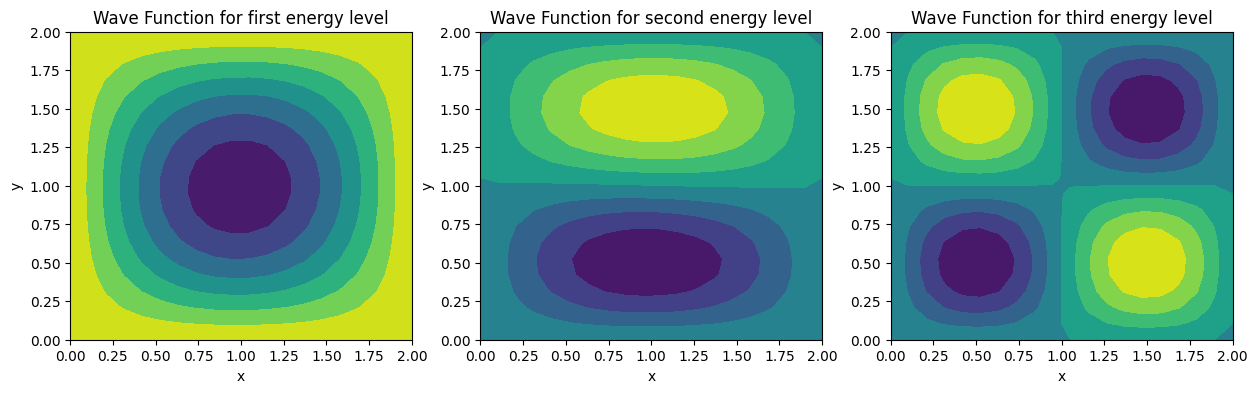

In [21]:
# Plot predicted solutions from classical neural network
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].contourf(X, Y, psi_pred1.detach().numpy(), cmap='viridis')
axs[0].set_title('Wave Function for first energy level')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# Second plot
axs[1].contourf(X, Y, psi_pred2.detach().numpy(), cmap='viridis')
axs[1].set_title('Wave Function for second energy level')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

# Third plot
axs[2].contourf(X, Y, psi_pred3.detach().numpy(), cmap='viridis')
axs[2].set_title('Wave Function for third energy level')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
plt.show()

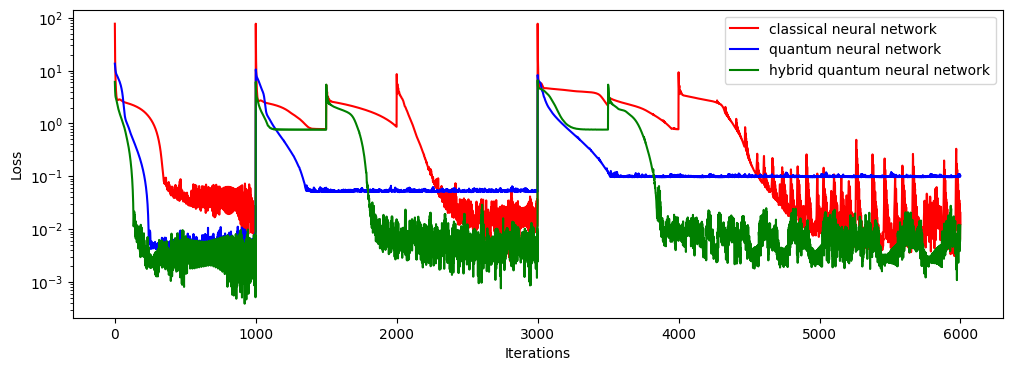

In [22]:
# Plot loss function versus iteration on a semilogarithmic scale for classical, quantum, and hybrid neural networks
l1 = c_hist3[0][0] + c_hist3[1][0] + c_hist3[2][0]
l2 = q_hist2[0][0] + q_hist2[1][0] + q_hist2[2][0]
l3 = h_hist2[0][0] + h_hist2[1][0] + h_hist2[2][0]


fig, axs = plt.subplots(1, 1, figsize=(12, 4))
plt.semilogy(l1, label= "classical neural network", color='red')
plt.semilogy(l2, label= "quantum neural network", color='blue')
plt.semilogy(l3, label= "hybrid quantum neural network", color='green')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

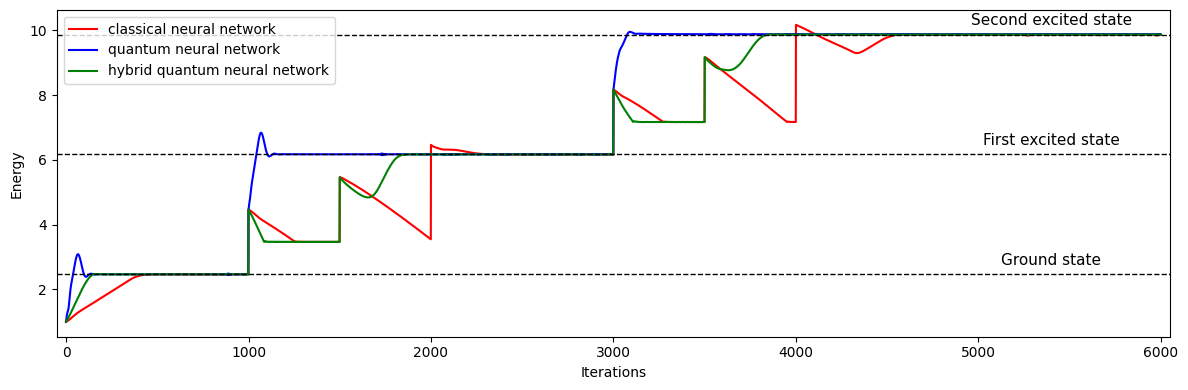

In [23]:
# Plot energy versus iteration for classical, quantum, and hybrid neural networks
l1 = c_hist3[0][3] + c_hist3[1][3] + c_hist3[2][3]
l2 = q_hist2[0][3] + q_hist2[1][3] + q_hist2[2][3]
l3 = h_hist2[0][3] + h_hist2[1][3] + h_hist2[2][3]

E1, E2, E3 = E_exact_list


fig, axs = plt.subplots(1, 1, figsize=(12, 4))

plt.plot(l1, label="classical neural network", color='red')
plt.plot(l2, label="quantum neural network", color='blue')
plt.plot(l3, label="hybrid quantum neural network", color='green')

# Dashed horizontal lines for energy levels
plt.axhline(y=E1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=E2, color='black', linestyle='--', linewidth=1)
plt.axhline(y=E3, color='black', linestyle='--', linewidth=1)

# Annotations
plt.text(x=len(l1) * 0.9, y=E1 + 0.2, s='Ground state', ha='center', va='bottom', fontsize=11, color='black')
plt.text(x=len(l2) * 0.9, y=E2 + 0.2, s='First excited state', ha='center', va='bottom', fontsize=11, color='black')
plt.text(x=len(l3) * 0.9, y=E3 + 0.2, s='Second excited state', ha='center', va='bottom', fontsize=11, color='black')

plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.xlim(-50,6050)
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\NAVID\\Desktop\\energy_predictions.png", bbox_inches="tight")


# Failed models

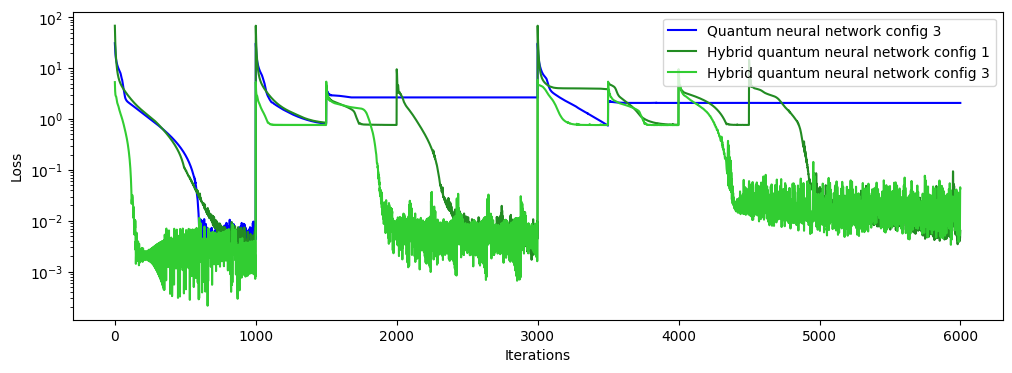

In [24]:
# Plot the loss function versus iterations on a semilogarithmic scale for the failed quantum and hybrid neural networks
l1 = q_hist3[0][0] + q_hist3[1][0] + q_hist3[2][0]
l2 = h_hist1[0][0] + h_hist1[1][0] + h_hist1[2][0]
l3 = h_hist3[0][0] + h_hist3[1][0] + h_hist3[2][0]


fig, axs = plt.subplots(1, 1, figsize=(12, 4))
plt.semilogy(l1, label="Quantum neural network config 3", color='blue')
plt.semilogy(l2, label="Hybrid quantum neural network config 1", color='forestgreen')
plt.semilogy(l3, label="Hybrid quantum neural network config 3", color='limegreen')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.show()

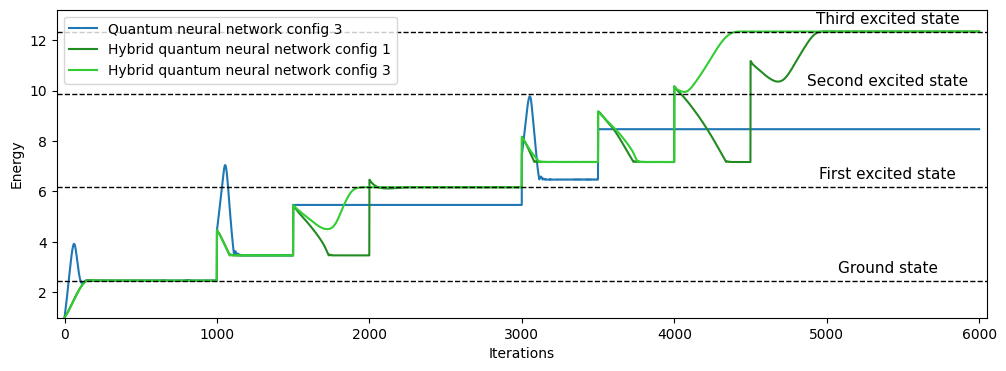

In [25]:
# Plot the energy versus iterations on a semilogarithmic scale for the failed quantum and hybrid neural networks

l1 = q_hist3[0][3] + q_hist3[1][3] + q_hist3[2][3]
l2 = h_hist1[0][3] + h_hist1[1][3] + h_hist1[2][3]
l3 = h_hist3[0][3] + h_hist3[1][3] + h_hist3[2][3]

E1, E2, E3 = E_exact_list


fig, axs = plt.subplots(1, 1, figsize=(12, 4))

plt.plot(l1, label="Quantum neural network config 3")

plt.plot(l2, label="Hybrid quantum neural network config 1", color='forestgreen')

plt.plot(l3, label="Hybrid quantum neural network config 3", color='limegreen')


# Dashed horizontal lines for energy levels
plt.axhline(y=E1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=E2, color='black', linestyle='--', linewidth=1)
plt.axhline(y=E3, color='black', linestyle='--', linewidth=1)
plt.axhline(y=E4, color='black', linestyle='--', linewidth=1)
# Annotations
plt.text(x=len(l1) * 0.9, y=E1 + 0.2, s='Ground state', ha='center', va='bottom', fontsize=11, color='black')
plt.text(x=len(l2) * 0.9, y=E2 + 0.2, s='First excited state', ha='center', va='bottom', fontsize=11, color='black')
plt.text(x=len(l3) * 0.9, y=E3 + 0.2, s='Second excited state', ha='center', va='bottom', fontsize=11, color='black')
plt.text(x=len(l3) * 0.9, y=E4 + 0.2, s='Third excited state', ha='center', va='bottom', fontsize=11, color='black')

plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.ylim(1, 13.2)
plt.xlim(-50,6050)
plt.legend()
plt.show()